# Customer Intelligence & Revenue Analytics Platform




## Table of Contents

1. [Project Introduction](#project-introduction)
2. [Business Problem](#business-problem)
3. [Dataset Overview](#dataset-overview)
4. [Setup and Data Loading](#setup-and-data-loading)
5. [Initial Data Inspection](#initial-data-inspection)
6. [Data Cleaning and Preparation](#data-cleaning-and-preparation)
7. [Creating Useful Columns](#creating-useful-columns)
8. [Checking and Removing a Duplicate Column](#checking-and-removing-a-duplicate-column)
9. [MySQL Database Integration](#mysql-database-integration)

## Project Introduction

The purpose of this project is to work with customer shopping behavior data and prepare it for further analysis. The notebook currently covers data loading, basic inspection, cleaning, creation of a few useful columns, and storing the prepared data in a MySQL database.



## Business Problem

A retail business needs clean and organized customer data before it can study purchasing patterns and make better decisions. The main task at this stage is to check the quality of the data, handle missing values, standardize column names, and prepare useful fields that can support future customer behavior analysis.

## Dataset Overview

The dataset contains **4000 customer purchase records** and **18 original columns**. It includes:

- Customer details such as age, gender, and location
- Purchase details such as item, category, amount, size, color, and season
- Customer behavior details such as review rating, previous purchases, and purchase frequency
- Service and promotion details such as shipping type, subscription status, discounts, and promo code usage

The `Review Rating` column contains missing values, which are handled.

## Setup and Data Loading

This section imports the required Python library and loads the customer shopping behavior dataset into a pandas DataFrame.

In [5]:
import pandas as pd

df = pd.read_csv("customer_shopping_behavior.csv")

## Initial Data Inspection

The following cells display sample records, column data types, summary statistics, and missing-value counts. These checks give a basic understanding of the dataset before cleaning.

In [6]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [8]:
df.describe(include="all")

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [9]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

## Data Cleaning and Preparation

This section checks the quality of the dataset and makes only the changes needed to keep the data consistent. 

### 1. Dataset Shape Before Cleaning

The number of rows and columns is recorded before cleaning. This gives a starting point that can be compared with the final dataset shape.

In [10]:
shape_before_cleaning = df.shape

shape_before_table = pd.DataFrame(
    {
        "stage": ["Before Cleaning"],
        "rows": [shape_before_cleaning[0]],
        "columns": [shape_before_cleaning[1]],
    }
)

shape_before_table

,stage,rows,columns
0,Before Cleaning,3900,18


### 2. Standardizing Column Names

Consistent column names make the dataset easier to use in Python. All names are converted to lowercase, special characters are replaced with underscores, and extra underscores are removed. The purchase amount column keeps the shorter name used in the original project.

In [11]:
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

df.rename(
    columns={"purchase_amount_usd": "purchase_amount"},
    inplace=True,
)

pd.DataFrame({"standardized_column_names": df.columns})

,standardized_column_names
0,customer_id
1,age
2,gender
3,item_purchased
4,category
5,purchase_amount
6,location
7,size
8,color
9,season


### 3. Verifying and Correcting Data Types

Columns used for calculations should be numeric, while descriptive columns should be stored as text. Numeric conversion also helps reveal unexpected text values because values that cannot be converted become missing and are reported in the next step.

In [12]:
numeric_columns = [
    "customer_id",
    "age",
    "purchase_amount",
    "review_rating",
    "previous_purchases",
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

text_columns = df.select_dtypes(include="object").columns

for column in text_columns:
    df[column] = df[column].astype("string").str.strip()

data_types_table = (
    df.dtypes.astype(str)
    .rename("data_type")
    .rename_axis("column")
    .reset_index()
)

data_types_table

,column,data_type
0,customer_id,int64
1,age,int64
2,gender,string
3,item_purchased,string
4,category,string
5,purchase_amount,int64
6,location,string
7,size,string
8,color,string
9,season,string


### 4. Checking Missing Values

Missing values can affect calculations and may reduce the reliability of later analysis. The table below reports the missing count and percentage for every column before any values are filled.

In [13]:
missing_values_before = df.isnull().sum()

missing_values_before_table = pd.DataFrame(
    {
        "missing_values": missing_values_before,
        "missing_percentage": (
            missing_values_before / len(df) * 100
        ).round(2),
    }
).rename_axis("column")

missing_values_before_table

,missing_values,missing_percentage
column,,
customer_id,0,0.00
age,0,0.00
gender,0,0.00
item_purchased,0,0.00
category,0,0.00
purchase_amount,0,0.00
location,0,0.00
size,0,0.00
color,0,0.00


### 5. Handling Missing Review Ratings

The missing values occur in `review_rating`. A category median is used because ratings may differ between product categories, and the median is less affected by unusually high or low ratings. The comparison table confirms the missing-value count before and after treatment.

In [14]:
df["review_rating"] = (
    df.groupby("category")["review_rating"]
    .transform(lambda values: values.fillna(values.median()))
)

missing_values_after = df.isnull().sum()

missing_values_table = pd.DataFrame(
    {
        "missing_values_before": missing_values_before,
        "missing_values_after": missing_values_after,
        "missing_percentage_before": (
            missing_values_before / len(df) * 100
        ).round(2),
    }
).rename_axis("column")

missing_values_table

,missing_values_before,missing_values_after,missing_percentage_before
column,,,
customer_id,0,0,0.00
age,0,0,0.00
gender,0,0,0.00
item_purchased,0,0,0.00
category,0,0,0.00
purchase_amount,0,0,0.00
location,0,0,0.00
size,0,0,0.00
color,0,0,0.00


### 6. Checking Duplicate Records

Duplicate rows can count the same customer purchase more than once. The dataset is checked for complete duplicate records, and duplicates are removed only when they are present.

In [15]:
duplicate_records_before = df.duplicated().sum()

if duplicate_records_before > 0:
    df.drop_duplicates(inplace=True)

duplicate_records_after = df.duplicated().sum()

duplicate_records_table = pd.DataFrame(
    {
        "stage": ["Before Cleaning", "After Cleaning"],
        "duplicate_records": [
            duplicate_records_before,
            duplicate_records_after,
        ],
    }
)

duplicate_records_table

,stage,duplicate_records
0,Before Cleaning,0
1,After Cleaning,0


### 7. Checking Invalid Numeric Values

Important numeric columns are checked against simple business rules. Customer IDs must be positive, ages should be between 0 and 100, purchase amounts must be greater than zero, ratings must be between 0 and 5, and previous purchases cannot be negative. This is a validation step and does not add any new analysis.

In [53]:
invalid_value_checks = {
    "Customer ID is zero or negative": df["customer_id"] <= 0,
    "Age is below 0 or above 120": ~df["age"].between(0, 100),
    "Purchase amount is zero or negative": (
        df["purchase_amount"] <= 0
    ),
    "Review rating is below 0 or above 5": (
        ~df["review_rating"].between(0, 5)
    ),
    "Previous purchases is negative": (
        df["previous_purchases"] < 0
    ),
}

invalid_values_table = pd.DataFrame(
    {
        "validation_check": invalid_value_checks.keys(),
        "invalid_records": [
            check.sum() for check in invalid_value_checks.values()
        ],
    }
)

invalid_values_table

,validation_check,invalid_records
0,Customer ID is zero or negative,0
1,Age is below 0 or above 120,0
2,Purchase amount is zero or negative,0
3,Review rating is below 0 or above 5,0
4,Previous purchases is negative,0


### 8. Dataset Shape After Cleaning

The final shape is recorded to show whether duplicate removal changed the number of rows or whether any columns were removed during cleaning.

In [17]:
shape_after_cleaning = df.shape

dataset_shape_table = pd.DataFrame(
    {
        "stage": ["Before Cleaning", "After Cleaning"],
        "rows": [
            shape_before_cleaning[0],
            shape_after_cleaning[0],
        ],
        "columns": [
            shape_before_cleaning[1],
            shape_after_cleaning[1],
        ],
    }
)

dataset_shape_table

,stage,rows,columns
0,Before Cleaning,3900,18
1,After Cleaning,3900,18


## Data Cleaning Summary

The following cleaning work was completed:

- Recorded the dataset shape before and after cleaning
- Standardized all column names using lowercase letters and underscores
- Removed special characters from column names
- Verified numeric and text data types
- Reported missing-value counts and percentages
- Filled missing review ratings with the median rating of each category
- Checked for complete duplicate records and removed them only if present
- Checked important numeric columns for impossible or invalid values

For this dataset, 37 missing review ratings were filled. No complete duplicate rows or invalid numeric values were found

## Creating Useful Columns

This feature engineering section creates business-friendly columns from the  dataset. It keeps the original age-group and purchase-frequency features and adds purchase level and subscription binary.

### 1. Customer Age Group

**Why it is created:** Individual ages are grouped into four broader customer segments, which makes age-based comparisons easier to understand.

**Business value:** The business can use these groups to plan products, promotions, and communication for customers at different life stages.



In [18]:
# Create an age_group column
labels = ["Young_ Adult", "Adult", "Middele_aged", "Senior"]
df["age_group"] = pd.qcut(df["age"], q=4, labels=labels)

In [19]:
df[["age", "age_group"]].head()

,age,age_group
0,55,Middele_aged
1,19,Young_ Adult
2,50,Middele_aged
3,21,Young_ Adult
4,45,Middele_aged


### 2. Purchase Frequency in Days

**Why it is created:** The original purchase frequency is stored as text. Mapping it to an approximate number of days provides a consistent numeric measure while keeping the original column.

**Business value:** A numeric frequency makes it easier to identify customers who purchase more or less often and can support retention planning.



In [20]:
# Create a purchase_frequency_days column
frequency_mapping = {
    "Fortnightly": 14,
    "Weekly": 7,
    "Monthly": 30,
    "Quarterly": 90,
    "Bi-Weekly": 14,
    "Annually": 365,
    "Every 3 Months": 90,
}

df["purchase_frequency_days"] = df[
    "frequency_of_purchases"
].map(frequency_mapping)

In [21]:
df[
    ["frequency_of_purchases", "purchase_frequency_days"]
].head()

,frequency_of_purchases,purchase_frequency_days
0,Fortnightly,14
1,Fortnightly,14
2,Weekly,7
3,Weekly,7
4,Annually,365


### 3. Purchase Level

**Why it is created:** Purchase amounts are grouped into clear spending levels: **Low** for amounts below $50, **Medium** for amounts from $50 to $79, and **High** for amounts of $80 or more.

**Business value:** These levels provide a simple way to understand transaction value and support spending-based customer targeting.



In [22]:
# Create a purchase_level column
purchase_level_bins = [0, 50, 80, float("inf")]
purchase_level_labels = ["Low", "Medium", "High"]

df["purchase_level"] = pd.cut(
    df["purchase_amount"],
    bins=purchase_level_bins,
    labels=purchase_level_labels,
    right=False,
    include_lowest=True,
)

In [23]:
df[["purchase_amount", "purchase_level"]].head()

,purchase_amount,purchase_level
0,53,Medium
1,64,Medium
2,73,Medium
3,90,High
4,49,Low


### 4. Subscription Binary

**Why it is created:** The Yes/No subscription status is converted to 1/0 while the original text column is kept for readability.

**Business value:** A numeric subscription indicator is easier to aggregate and helps the business compare subscribers with non-subscribers.



In [24]:
# Create a subscription_binary column
subscription_mapping = {"Yes": 1, "No": 0}

df["subscription_binary"] = df["subscription_status"].map(
    subscription_mapping
)

In [25]:
df[["subscription_status", "subscription_binary"]].head()

,subscription_status,subscription_binary
0,Yes,1
1,Yes,1
2,Yes,1
3,Yes,1
4,Yes,1


## Feature Engineering Summary

Four engineered features are now available for later project stages:

| Engineered Feature | Purpose | Planned Later Use |
|---|---|---|
| `age_group` | Groups customers into broad age segments | EDA, SQL, Dashboard, ML |
| `purchase_frequency_days` | Converts purchase frequency text into approximate days | EDA, SQL, Dashboard, ML |
| `purchase_level` | Groups transactions into Low, Medium, and High spending levels | EDA, SQL, Dashboard, ML |
| `subscription_binary` | Converts subscription status from Yes/No to 1/0 | EDA, SQL, Dashboard, ML |

The original source columns are kept so the engineered values can be checked and clearly understood. No EDA, statistical analysis, SQL analysis, RFM, clustering, or machine learning is performed in this section.

# Exploratory Data Analysis (EDA)

This section explores the cleaned and prepared customer shopping data through simple visualizations. The purpose is to understand customer profiles, spending patterns, shopping behaviour, and basic relationships between variables.



### Visualization Setup



In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
chart_color = "#4C72B0"

## 1. Customer Demographics

**Business Question: Who are our customers?**

This section examines gender, age, and age groups to build a simple profile of the customers represented in the dataset.

### Gender Distribution

This count plot shows the number of customers recorded in each gender category. It helps identify whether the available customer base is balanced or concentrated in one group.

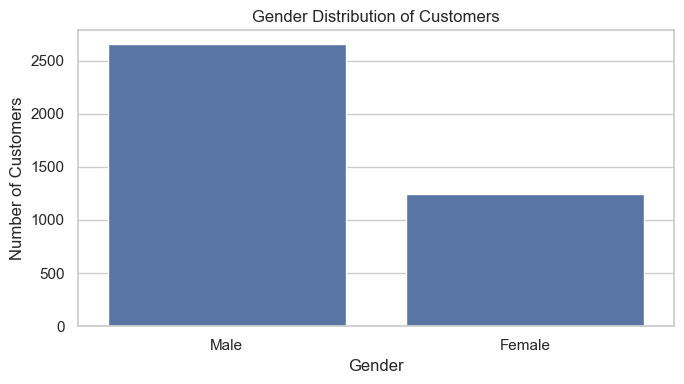

In [27]:
plt.figure(figsize=(7, 4))
ax = sns.countplot(
    data=df,
    x="gender",
    color=chart_color,
    order=df["gender"].value_counts().index,
)
ax.set_title("Gender Distribution of Customers")
ax.set_xlabel("Gender")
ax.set_ylabel("Number of Customers")
plt.tight_layout()
plt.show()

**Business Insight:** Male customers form the larger group with 2,652 records, compared with 1,248 female customers. This indicates that the current customer data is male-dominated, while the smaller female segment may offer room for more targeted engagement.

### Age Distribution

The histogram shows how customer ages are spread across the dataset. Understanding the age range helps the business plan products and communication for different life stages.

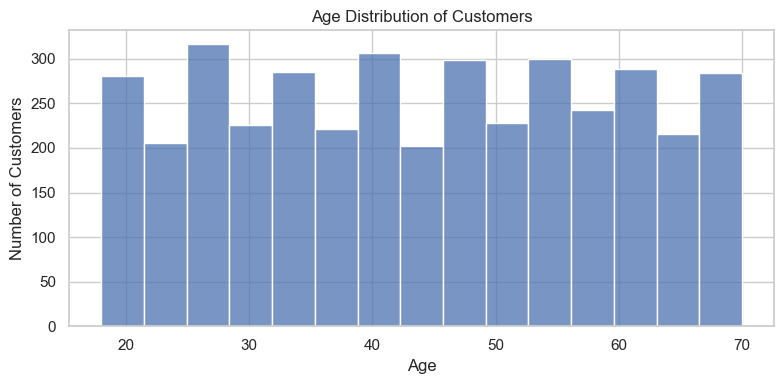

In [28]:
plt.figure(figsize=(8, 4))
ax = sns.histplot(
    data=df,
    x="age",
    bins=15,
    color=chart_color,
)
ax.set_title("Age Distribution of Customers")
ax.set_xlabel("Age")
ax.set_ylabel("Number of Customers")
plt.tight_layout()
plt.show()

**Business Insight:** Customer ages cover a wide range from 18 to 70 years, with an average age of about 44 years. The distribution is fairly spread out, showing that the business serves both younger and older customers rather than one narrow age segment.

### Age Group Distribution

This bar chart uses the engineered `age_group` feature to compare broader customer segments. Grouped ages are easier to use later in summaries and dashboard filters than individual age values.

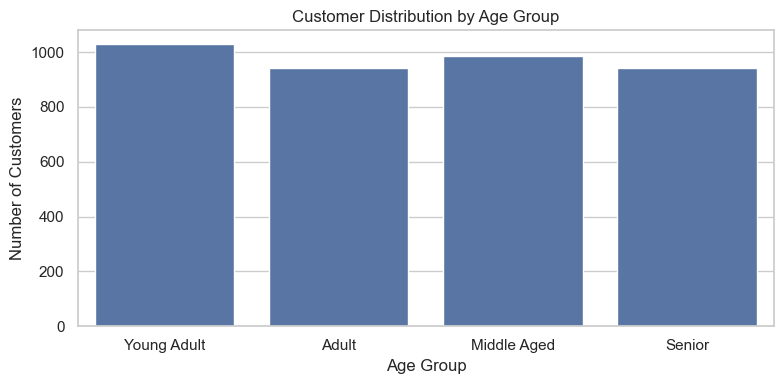

In [29]:
age_group_for_plot = df["age_group"].astype("string").replace(
    {
        "Young_ Adult": "Young Adult",
        "Middele_aged": "Middle Aged",
    }
)
age_group_order = [
    "Young Adult",
    "Adult",
    "Middle Aged",
    "Senior",
]

plt.figure(figsize=(8, 4))
ax = sns.countplot(
    x=age_group_for_plot,
    order=age_group_order,
    color=chart_color,
)
ax.set_title("Customer Distribution by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Number of Customers")
plt.tight_layout()
plt.show()

**Business Insight:** The four age groups are quite balanced, with each group containing roughly one-quarter of the records. Young Adults are slightly higher at 1,028 customers, but no single age group dominates the customer base.

## 2. Purchase Analysis

**Business Question: How do customers spend?**

This section reviews purchase amounts and compares average spending across product categories and subscription groups.

### Purchase Amount Distribution

This histogram shows the range and frequency of transaction amounts. It helps identify whether customer purchases are mainly low-value, high-value, or spread across different spending levels.

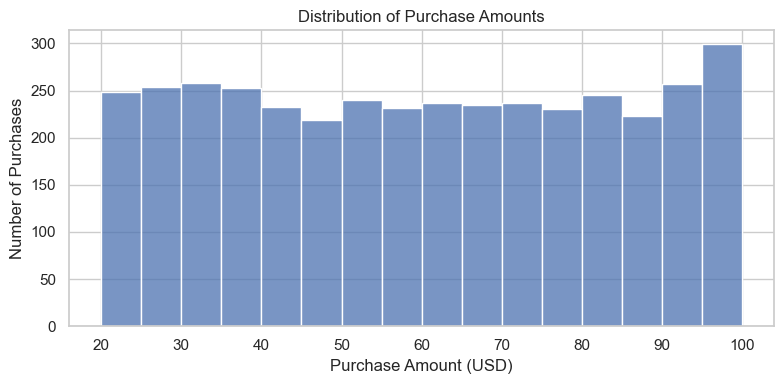

In [30]:
plt.figure(figsize=(8, 4))
ax = sns.histplot(
    data=df,
    x="purchase_amount",
    bins=16,
    color=chart_color,
)
ax.set_title("Distribution of Purchase Amounts")
ax.set_xlabel("Purchase Amount (USD)")
ax.set_ylabel("Number of Purchases")
plt.tight_layout()
plt.show()

**Business Insight:** Purchase amounts range from $20 to $100 and are spread fairly evenly across this range. The average purchase is about $59.76 and the median is $60, suggesting that there is no strong concentration at only the low or high end.

### Average Purchase Amount by Product Category

The bar chart compares the average transaction amount for each product category. This makes it easier to see which categories generate higher-value purchases on average.

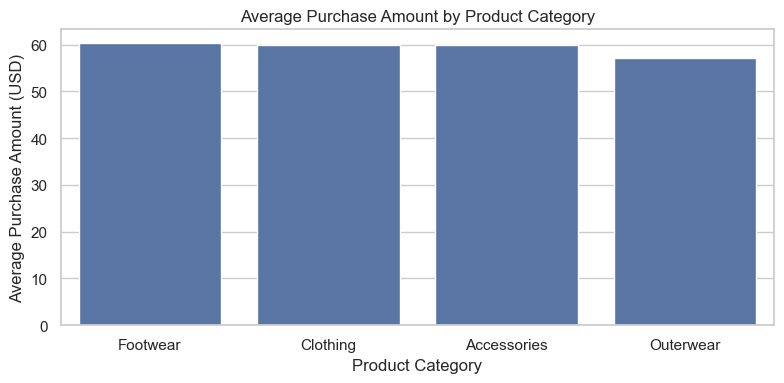

In [31]:
category_purchase = (
    df.groupby("category", observed=False)["purchase_amount"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=category_purchase,
    x="category",
    y="purchase_amount",
    color=chart_color,
)
ax.set_title("Average Purchase Amount by Product Category")
ax.set_xlabel("Product Category")
ax.set_ylabel("Average Purchase Amount (USD)")
plt.tight_layout()
plt.show()

**Business Insight:** Footwear has the highest average purchase amount at about $60.26, closely followed by Clothing and Accessories. Outerwear is slightly lower at about $57.17, but the small difference shows that average spending is generally consistent across categories.

### Average Purchase Amount by Subscription Status

This chart compares average transaction value for subscribers and non-subscribers. It provides an early view of whether subscription membership is connected with higher spending per purchase.

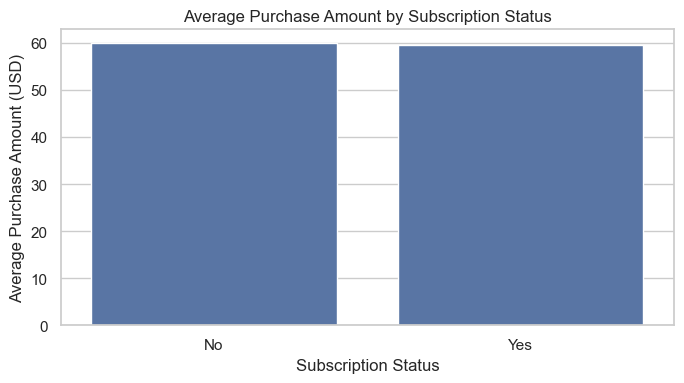

In [32]:
subscription_purchase = (
    df.groupby("subscription_status", observed=False)[
        "purchase_amount"
    ]
    .mean()
    .reset_index()
)

plt.figure(figsize=(7, 4))
ax = sns.barplot(
    data=subscription_purchase,
    x="subscription_status",
    y="purchase_amount",
    color=chart_color,
)
ax.set_title("Average Purchase Amount by Subscription Status")
ax.set_xlabel("Subscription Status")
ax.set_ylabel("Average Purchase Amount (USD)")
plt.tight_layout()
plt.show()

**Business Insight:** Subscribers spend about $59.49 per purchase, while non-subscribers spend about $59.87. The difference is very small, so subscription status does not appear to separate customers by transaction value in this dataset.

## 3. Customer Behaviour

**Business Question: How do customers shop?**

This section looks at customers' previous purchase history and their selected shipping methods to understand repeat-shopping activity and delivery preferences.

### Previous Purchases Distribution

The histogram shows how many previous purchases customers have made. It gives a simple view of whether the dataset contains mainly newer customers or experienced repeat shoppers.

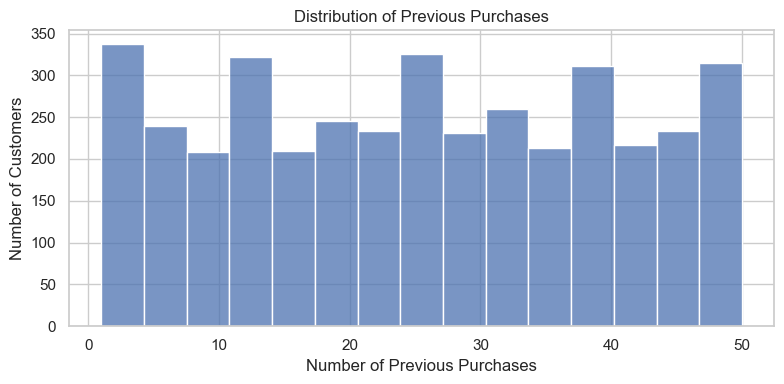

In [33]:
plt.figure(figsize=(8, 4))
ax = sns.histplot(
    data=df,
    x="previous_purchases",
    bins=15,
    color=chart_color,
)
ax.set_title("Distribution of Previous Purchases")
ax.set_xlabel("Number of Previous Purchases")
ax.set_ylabel("Number of Customers")
plt.tight_layout()
plt.show()

**Business Insight:** Previous purchases range from 1 to 50, with a median of 25 and an average of about 25.35. The broad distribution suggests that the dataset contains a mix of relatively new customers and customers with a longer purchase history.

### Shipping Type Distribution

This count plot compares the use of each shipping option. It helps the business understand customer delivery preferences and supports future planning for shipping services.

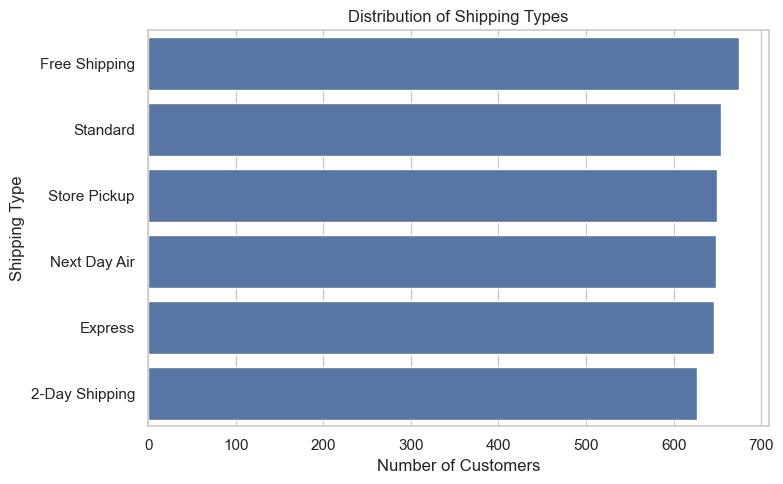

In [34]:
shipping_order = df["shipping_type"].value_counts().index

plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df,
    y="shipping_type",
    order=shipping_order,
    color=chart_color,
)
ax.set_title("Distribution of Shipping Types")
ax.set_xlabel("Number of Customers")
ax.set_ylabel("Shipping Type")
plt.tight_layout()
plt.show()

**Business Insight:** Shipping choices are well balanced, with counts ranging from 627 to 675. Free Shipping is the most selected option, but its lead is small, showing that customers use all available delivery methods rather than relying on only one.

## 4. Relationship Analysis

**Business Question: Are there relationships between different variables?**

This section uses a correlation heatmap and a scatter plot to check for simple linear relationships between the main numerical measures.

### Correlation Heatmap

The heatmap compares numerical measures using correlation values from -1 to 1. Customer ID is excluded because it is an identifier rather than a business measure.

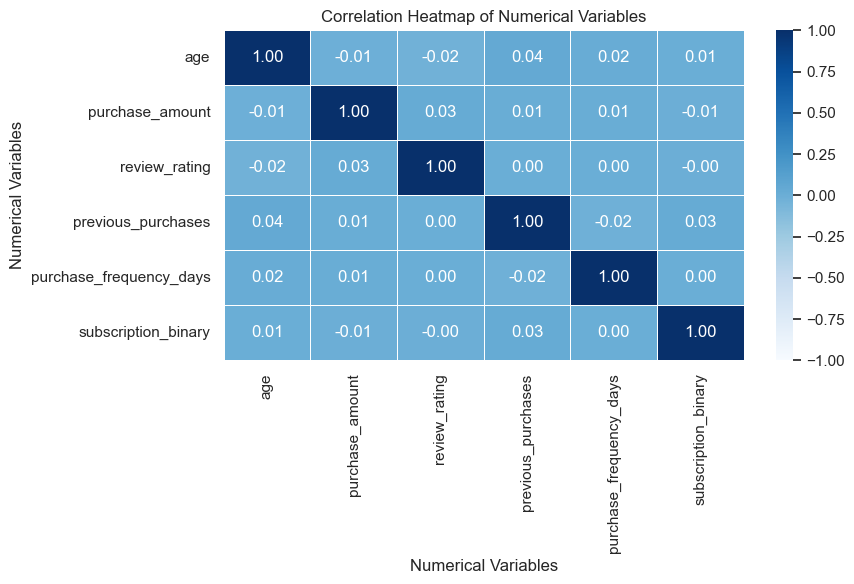

In [35]:
numerical_columns = [
    "age",
    "purchase_amount",
    "review_rating",
    "previous_purchases",
    "purchase_frequency_days",
    "subscription_binary",
]
correlation_matrix = df[numerical_columns].corr()

plt.figure(figsize=(9, 6))
ax = sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
)
ax.set_title("Correlation Heatmap of Numerical Variables")
ax.set_xlabel("Numerical Variables")
ax.set_ylabel("Numerical Variables")
plt.tight_layout()
plt.show()

**Interpretation:** The numerical variables have very weak correlations, with absolute values close to zero. This means that no strong linear relationship is visible among age, spending, ratings, purchase history, purchase frequency, and subscription status.

### Age vs Purchase Amount

The scatter plot checks whether purchase amounts tend to rise or fall as customer age changes. Each point represents one customer record.

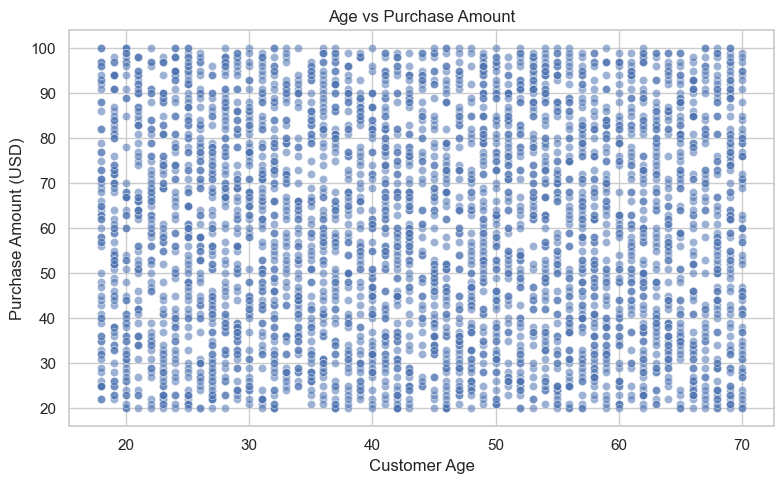

In [36]:
plt.figure(figsize=(8, 5))
ax = sns.scatterplot(
    data=df,
    x="age",
    y="purchase_amount",
    color=chart_color,
    alpha=0.55,
    s=35,
)
ax.set_title("Age vs Purchase Amount")
ax.set_xlabel("Customer Age")
ax.set_ylabel("Purchase Amount (USD)")
plt.tight_layout()
plt.show()

**Interpretation:** Purchase amounts are spread across the full value range for customers of nearly every age. The correlation is approximately -0.01, indicating that age alone has almost no linear relationship with purchase amount in this dataset.

## EDA Summary

The visual analysis shows a broad customer age range, a larger male customer segment, and balanced age groups. Purchase values are spread from $20 to $100, while average spending differs only slightly across product categories and subscription groups.

Previous-purchase counts and shipping choices are also broadly distributed. The relationship analysis does not show strong linear connections between the main numerical variables, so these factors should be considered together in future dashboard or modelling work rather than interpreted separately.

# Customer Segmentation

## Business Objective

The purpose of this section is to group customers using simple business rules. These segments make customer behaviour and spending patterns easier to understand without using machine learning or clustering algorithms.

## 1. Customer Loyalty Segment

The `Customer_Segment` column is created from `previous_purchases`:

- **New Customer:** 0 previous purchases
- **Returning Customer:** 1 to 10 previous purchases
- **Loyal Customer:** More than 10 previous purchases

This rule helps the business separate customers by purchase history. The original `previous_purchases` column is kept so the segment can be verified.

In [37]:
loyalty_bins = [-1, 0, 10, float("inf")]
loyalty_labels = [
    "New Customer",
    "Returning Customer",
    "Loyal Customer",
]

df["Customer_Segment"] = pd.cut(
    df["previous_purchases"],
    bins=loyalty_bins,
    labels=loyalty_labels,
)

### Verifying the Customer Loyalty Segment

The first few rows are displayed to confirm that each previous-purchase value has been assigned to the correct customer segment.

In [38]:
df[["previous_purchases", "Customer_Segment"]].head()

,previous_purchases,Customer_Segment
0,14,Loyal Customer
1,2,Returning Customer
2,23,Loyal Customer
3,49,Loyal Customer
4,31,Loyal Customer


### Customer Segment Distribution

The count plot compares the number of customers in each loyalty segment. This helps the business understand whether its customer base is mainly new, returning, or loyal.

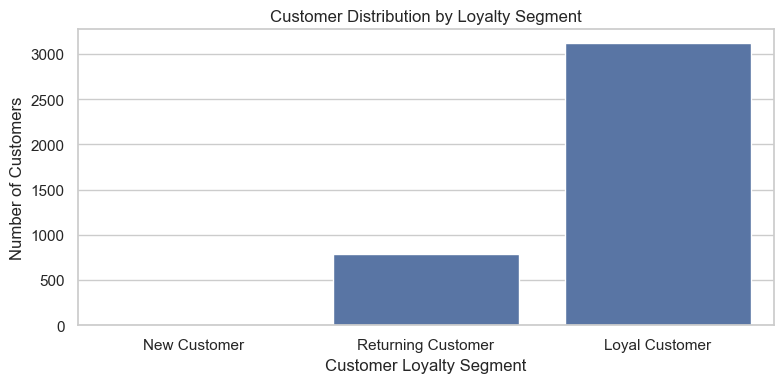

In [39]:
loyalty_order = [
    "New Customer",
    "Returning Customer",
    "Loyal Customer",
]

plt.figure(figsize=(8, 4))
ax = sns.countplot(
    data=df,
    x="Customer_Segment",
    order=loyalty_order,
    color=chart_color,
)
ax.set_title("Customer Distribution by Loyalty Segment")
ax.set_xlabel("Customer Loyalty Segment")
ax.set_ylabel("Number of Customers")
plt.tight_layout()
plt.show()

**Business Insight:** Loyal Customers form the largest group with 3,116 records, while 784 customers are in the Returning Customer segment. There are no New Customers because every record in this dataset has at least one previous purchase.

### Total Revenue by Customer Segment

Total purchase revenue is calculated for each loyalty segment and displayed as a bar chart. This shows which group currently contributes the most revenue to the business.

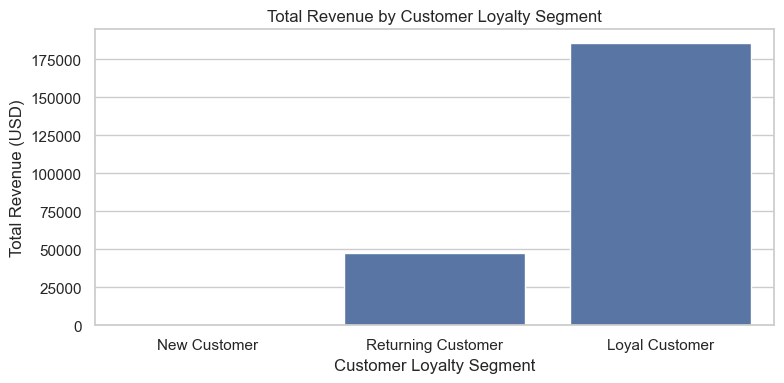

In [40]:
loyalty_revenue = (
    df.groupby("Customer_Segment", observed=False)[
        "purchase_amount"
    ]
    .sum()
    .reindex(loyalty_order)
    .reset_index()
)

plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=loyalty_revenue,
    x="Customer_Segment",
    y="purchase_amount",
    color=chart_color,
)
ax.set_title("Total Revenue by Customer Loyalty Segment")
ax.set_xlabel("Customer Loyalty Segment")
ax.set_ylabel("Total Revenue (USD)")
plt.tight_layout()
plt.show()

**Business Insight:** Loyal Customers generate the highest total revenue at $185,517, which is nearly 80% of the dataset's revenue. Returning Customers contribute $47,564, showing that moving more customers into the loyal group could have strong business value.

## 2. Spending Segment

The `Spending_Segment` column groups customers by `purchase_amount`. Because purchase amounts in this dataset range from $20 to $100, the suggested $200 and $500 limits would place every record in one group. The following limits are used instead so the segments are meaningful:

- **Low Spender:** Less than $50
- **Medium Spender:** $50 to $79
- **High Spender:** $80 or more

These limits match the existing purchase-level feature while providing the column name required for customer segmentation.

In [41]:
spending_bins = [0, 50, 80, float("inf")]
spending_labels = [
    "Low Spender",
    "Medium Spender",
    "High Spender",
]

df["Spending_Segment"] = pd.cut(
    df["purchase_amount"],
    bins=spending_bins,
    labels=spending_labels,
    right=False,
    include_lowest=True,
)

### Verifying the Spending Segment

The first few rows are displayed to check that each purchase amount has been placed into the correct spending segment.

In [42]:
df[["purchase_amount", "Spending_Segment"]].head()

,purchase_amount,Spending_Segment
0,53,Medium Spender
1,64,Medium Spender
2,73,Medium Spender
3,90,High Spender
4,49,Low Spender


### Spending Segment Distribution

The count plot compares the size of the three spending groups. This helps show which transaction-value segment is most common in the customer data.

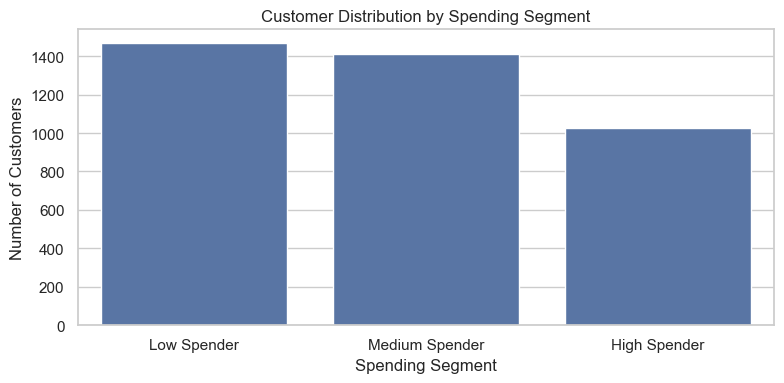

In [43]:
spending_order = [
    "Low Spender",
    "Medium Spender",
    "High Spender",
]

plt.figure(figsize=(8, 4))
ax = sns.countplot(
    data=df,
    x="Spending_Segment",
    order=spending_order,
    color=chart_color,
)
ax.set_title("Customer Distribution by Spending Segment")
ax.set_xlabel("Spending Segment")
ax.set_ylabel("Number of Customers")
plt.tight_layout()
plt.show()

**Business Insight:** Low Spenders are the largest group with 1,466 records, followed closely by 1,410 Medium Spenders. High Spenders account for 1,024 records, so the spending groups are reasonably balanced even though lower-value purchases are slightly more common.

### Average Purchase Amount by Spending Segment

The bar chart compares the average purchase amount within each spending group. This verifies that the business rules create clearly separated levels of transaction value.

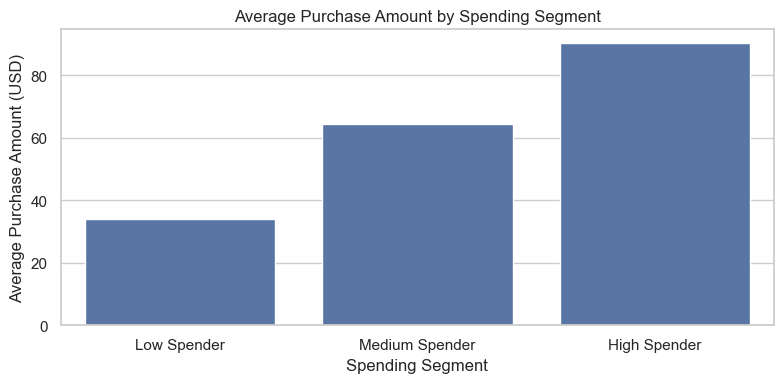

In [44]:
spending_average = (
    df.groupby("Spending_Segment", observed=False)[
        "purchase_amount"
    ]
    .mean()
    .reindex(spending_order)
    .reset_index()
)

plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=spending_average,
    x="Spending_Segment",
    y="purchase_amount",
    color=chart_color,
)
ax.set_title("Average Purchase Amount by Spending Segment")
ax.set_xlabel("Spending Segment")
ax.set_ylabel("Average Purchase Amount (USD)")
plt.tight_layout()
plt.show()

**Business Insight:** High Spenders have an average purchase amount of about $90.08, compared with $64.44 for Medium Spenders and $34.09 for Low Spenders. The clear differences confirm that the selected spending limits create useful business groups.

## Customer Segmentation Summary

- **Highest-revenue customer segment:** Loyal Customers generate the most revenue at $185,517.
- **Largest spending segment:** Low Spenders are the largest group with 1,466 records.
- **Suggested business action:** The company can reward Loyal Customers with retention benefits while using bundles, personalised offers, or minimum-spend discounts to encourage Low and Medium Spenders to move into a higher spending group.

This segmentation is based only on clear business rules. No machine learning, K-Means, RFM analysis, or clustering method is used.

## Checking and Removing a Duplicate Column

The discount and promo-code columns are compared to check whether they contain the same information. After the equality check, the duplicate promo-code column is removed and the remaining columns are reviewed.

In [45]:
df[["discount_applied", "promo_code_used"]].head()

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes


In [46]:
(df["discount_applied"] == df["promo_code_used"]).all()

np.True_

In [47]:
df = df.drop("promo_code_used", axis=1)

In [48]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days',
       'purchase_level', 'subscription_binary', 'Customer_Segment',
       'Spending_Segment'],
      dtype='object')

## MySQL Database Integration

The prepared DataFrame is connected to a MySQL database and saved as a table. The final query checks that the data was imported correctly.

### Installing Database Libraries

The required packages for connecting pandas to MySQL are installed in the notebook environment.

In [49]:
!pip install pymysql sqlalchemy

### Creating the Database Connection

SQLAlchemy is used to create a connection engine for the `customer_behavior` MySQL database.

In [50]:
from urllib.parse import quote_plus

from sqlalchemy import create_engine

username = "root"
password = quote_plus("Jais1234@")  # âœ… safely encoded
host = "127.0.0.1"
port = "3306"
database = "customer_behavior"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

print("âœ… Engine created successfully!")

âœ… Engine created successfully!


### Checking Existing Tables

This query checks which tables already exist in the selected database before the DataFrame is imported.

In [51]:
pd.read_sql("SHOW TABLES;", engine)

,Tables_in_customer_behavior
0,customer


### Importing and Verifying the Data

The cleaned DataFrame is written to the `customer` table. A small SQL query is then used to display the first five records and verify the import.

In [ ]:
# Fix column names 
df.columns = df.columns.str.replace(" ", "_")

# MySQL connection
username = "root"
password = quote_plus("Jais1234@")
host = "127.0.0.1"
port = "3306"
database = "customer_behavior"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

# Write DataFrame
table_name = "customer"
df.to_sql(table_name, engine, if_exists="replace", index=False)

print("âœ… Data imported!")

# Verify
pd.read_sql("SELECT * FROM customer LIMIT 5;", engine)

âœ… Data imported!


,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,...,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days,purchase_level,subscription_binary,Customer_Segment,Spending_Segment
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Yes,14,Venmo,Fortnightly,Middele_aged,14,Medium,1,Loyal Customer,Medium Spender
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Yes,2,Cash,Fortnightly,Young_ Adult,14,Medium,1,Returning Customer,Medium Spender
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Yes,23,Credit Card,Weekly,Middele_aged,7,Medium,1,Loyal Customer,Medium Spender
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,Yes,49,PayPal,Weekly,Young_ Adult,7,High,1,Loyal Customer,High Spender
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,Yes,31,PayPal,Annually,Middele_aged,365,Low,1,Loyal Customer,Low Spender
